# Analysis of object detection models

The objective of this work is to identify a suitable CPU-friendly object detection model. In my system, the object detection will be used to propose bounding boxes around the physical objects in an image, after which the user manually select the object they want to track and name it.

 Therefore, the detector is not required to perform detailed classification, it just needs to be able to provide reliable localisation with low latency.

## Model selection strategy

A set of lightweight and commonly used object detection model families was selected for comparison. For each family, a representative small or CPU-orientated variant was chosen to ensure fair evaluation.

The evaluated models include 
- YOLOv8n
- SSDLite MobileNet V3 large
- EfficientDet-D0
- Faster R-CNN with a ResNet-50 FPN backbone

The models above will first be compared at the family level to identify the most suitable detection approach for the given use case. Subsequently, further exploration within the selected model family will be conducted to evaluate the trade-off between detection accuracy and computational efficiency across different model scales, ensuring that the final model choice balances localisation performance with CPU inference latency.

## Evaluation Metrics

The models will be evaluated using standard object detection metrics:

- Mean Average Precision: To measure the overall detection performance
- Intersection over Union(IoU): To access the quality of the bounding box localisation
- inference time on CPU(milliseconds per image): To evaluate runtime efficiency
- end to end latency: To evaluate response time

The evaluation was conducted using a three-stage benchmarking procedure to assess both detection accuracy and computational performance of the selected pretrained object detection models. As no fine-tuning or retraining was performed, all models were evaluated using their original pretrained weights under identical inference conditions to ensure a fair and reproducible comparison.

In the first stage, all evaluated models were tested on a product-centric dataset to measure bounding box localisation quality and baseline object detection performance using the above metrics. This stage served to identify models that demonstrate strong localisation performance while remaining computationally feasible for CPU-based deployment.

Although the intended application allows users to manually identify the target object, class labels were retained during evaluation to enable the use of standard object detection metrics such as mAP and IoU. During deployment, class predictions for the target object are not required, and only bounding box localisation and confidence scores are utilised.

In the second stage, the top-performing models identified in Stage 1 were evaluated on a separate context-focused dataset containing labelled surrounding objects such as furniture. This evaluation assessed each model’s ability to detect supporting objects relevant to the intended application, such as identifying whether a target object is placed on a sofa, desk, or similar surface.

In the final stage, the selected top-performing model was compared against a larger variant within the same model family to analyse accuracy–latency trade-offs and assess whether increased model capacity provides meaningful performance gains under the same deployment constraints.

## Methology

### Stage 1

The dataset was sourced from Roboflow Universe and contains annotated images of items in indoor settings. The dataset was exported in COCO JSON format and downloaded locally for offline evaluation. No training, augmentation, or fine-tuning was performed, and all experiments were conducted using the validation split.

The helper function to measure the inference time and end to end latency is as shown below

#### Yolov8n

The yolov8n model will first be evalauted

In [ ]:
from ultralytics import YOLO
import torch

# specically defining CPU
device = "cpu"

# loading the pretrained model
model = YOLO("yolov8n.pt")
# transfering models weights to device
model.to(device)



YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

Doing a model warmup to ensure consistent testing

In [ ]:
import numpy as np
# creating image and 3 color channels
dummy = np.zeros((640, 640, 3), dtype=np.uint8)
# performing a warmup inference to initialize the model layers and memory
_ = model(dummy, device=device, verbose=False)


To verify that the bounding boxes are generated, a quick test is done to ensure that the model works as intended

(np.float64(-0.5), np.float64(415.5), np.float64(415.5), np.float64(-0.5))

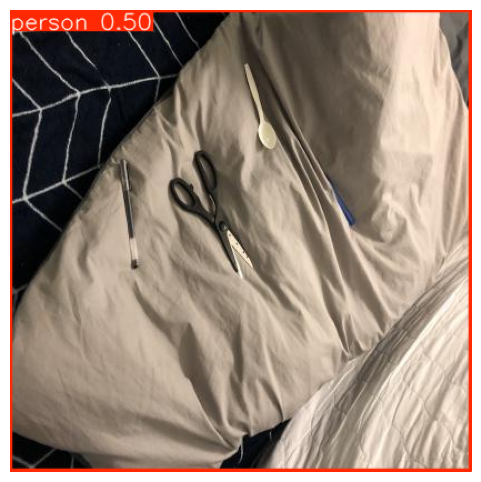

In [ ]:
import cv2
import matplotlib.pyplot as plt

# loading the specific training image from the dataset using OpenCV
img = cv2.imread("household.v1i.coco/train/IMG_3239_JPG_jpg.rf.667b6c9162b47abd99046450fd8dc5dd.jpg")
# making sure that the image is in RGB so it is suitable for YOLO
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# run inference on the loaded image
results = model(img, device="cpu", verbose=False)

# drawing the predicted bounding boxes
annotated_img = results[0].plot()

plt.figure(figsize=(6, 6))
plt.imshow(annotated_img)
plt.axis("off")


Function to measure the inference time

In [ ]:
import time

def measure_inference(forward_fn, model, input_data, runs=50):
    times = []

    # warm-up loop
    for _ in range(5):
        _ = forward_fn(model, input_data)
    # bench marking loop to calculate the start and end time
    for _ in range(runs):
        start = time.perf_counter()
        _ = forward_fn(model, input_data)
        end = time.perf_counter()
        times.append((end - start) * 1000)

    return {
        "median_ms": float(np.median(times)),
        "p90_ms": float(np.percentile(times, 90))
    }


Function to measure the end to end latency

In [ ]:
def measure_end_to_end(forward_fn, model, preprocess_fn, image_path, runs=50):
    times = []

    # warm-up
    for _ in range(5):
        inp = preprocess_fn(image_path)
        _ = forward_fn(model, inp)
    # benchmarking
    for _ in range(runs):
        start = time.perf_counter()
        # reading the file
        inp = preprocess_fn(image_path)
        # running model
        _ = forward_fn(model, inp)

        end = time.perf_counter()
        # calculate time taken
        times.append((end - start) * 1000)

    return {
        "median_ms": float(np.median(times)),
        "p90_ms": float(np.percentile(times, 90))
    }


Helper wrapper functions

In [ ]:
import cv2
# standardizing image loading for pipeline
def preprocess_yolo(image_path):
    img = cv2.imread(image_path)
    return img
# wrapping the model call into a consistent format for benchmarking
def yolo_forward(model, img):
    return model(img, device="cpu", verbose=False)



Verification step to ensure that the inference and the end to end functions is able to work with the YOLO 

In [ ]:
# using a specific image form the dataset
image_path = "household.v1i.coco/train/IMG_3239_JPG_jpg.rf.667b6c9162b47abd99046450fd8dc5dd.jpg"
# using the helper function to load the image into memory once
img = preprocess_yolo(image_path)
# measureing the inference and the end to end time
yolo_inf = measure_inference(yolo_forward, model, img)
yolo_e2e = measure_end_to_end(yolo_forward, model, preprocess_yolo, image_path)

print("YOLO inference:", yolo_inf)
print("YOLO end-to-end:", yolo_e2e)


YOLO inference: {'median_ms': 51.63924989756197, 'p90_ms': 58.62102007959038}
YOLO end-to-end: {'median_ms': 52.05084988847375, 'p90_ms': 57.15871008578688}


For testing of the model, COCO API is used to automate the evaluation process across the entire validation set. By accessing the annotations json file, the system will be able to compare the YOLO real time detections against the ground truth labels, providing a good measurement of performance

In [ ]:
import os
import time
import cv2
import numpy as np
from ultralytics import YOLO
from pycocotools.coco import COCO

# defining the dataset paths for the validation set
DATA_DIR = "household.v1i.coco/valid"
IMG_DIR = os.path.join(DATA_DIR)
ANN_PATH = os.path.join(DATA_DIR, "_annotations.coco.json")

# Load COCO ground truth
coco = COCO(ANN_PATH)
# retrieving a list of all unique image IDS in the validation set
image_ids = coco.getImgIds()

# Load YOLOv8n (CPU)
device = "cpu"
model = YOLO("yolov8n.pt")
model.to(device)

# Warm-up
first_img_id = image_ids[0]
img_info = coco.loadImgs(first_img_id)[0]
img_path = os.path.join(IMG_DIR, img_info["file_name"])

dummy = cv2.imread(img_path)
_ = model(dummy, device=device, verbose=False)


loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


Function to calculate the intersection over Union, which is used for measuring the accuracy of an object detector by comparing the predicted bounding box to the ground truth

In [ ]:
def compute_iou(boxA, boxB):
    # determining the coordinates of the intersection rectangle
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # calculate the area of the overalap
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    # calculating the union area
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0


In this system, object detection is used to propose candidate crops for user selection and subsequent embedding-based instance matching, rather than to achieve tight localisation. Therefore, localisation performance is evaluated using recall at a relaxed IoU threshold of 0.3, reflecting the minimum overlap required to produce a usable crop for interaction and similarity computation.

This loop evaluates the system by iterating through the validation dataset to measure latency and Localization Accuracy simultaneously. By comparing the model's predicted bounding boxes against the COCO "ground truth" using the Intersection over Union (IoU) metric, we can quantify how reliably the system identifies misplaced items. Any detection exceeding the IOU_THRESHOLD is recorded as a "hit," providing a clear success rate for the project's object locator.

While the previous measure functions were useful for isolated benchmarking, they were replaced here to avoid the computational overhead of running the model twice for every image, once for timing and once for accuracy.

In [ ]:
# minimum overlap required to consider a detection "successful"
IOU_THRESHOLD = 0.3

all_ious = []
hits = 0
total_gt = 0

inf_times = []
e2e_times = []
# iterating through everay image in the validation dataset
for img_id in image_ids:
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(IMG_DIR, img_info["file_name"])

    # Load image
    start_e2e = time.perf_counter()
    img = cv2.imread(img_path)

    # Inference timing
    start_inf = time.perf_counter()
    results = model(img, device=device, verbose=False)
    end_inf = time.perf_counter()

    end_e2e = time.perf_counter()
    # Time recording in miliseconds
    inf_times.append((end_inf - start_inf) * 1000)
    e2e_times.append((end_e2e - start_e2e) * 1000)

    # Predicted boxes extractions 
    preds = results[0].boxes.xyxy.cpu().numpy()

    # Retrieving the ground truth annotations for this specific image
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)
    # converting COCO formate to match YOLO
    gt_boxes = []
    for ann in anns:
        x, y, w, h = ann["bbox"]
        gt_boxes.append([x, y, x + w, y + h])

    # IoU matching
    for gt in gt_boxes:
        total_gt += 1
        best_iou = 0.0
        # for every ground truth object, find the prediction that overlaps the most
        for pred in preds:
            iou = compute_iou(gt, pred)
            best_iou = max(best_iou, iou)

        all_ious.append(best_iou)
        # count as a hit if the best prediction exceeds the threshold
        if best_iou >= IOU_THRESHOLD:
            hits += 1


Calculation of the evaluation metrics

In [11]:
mean_iou = float(np.mean(all_ious))
recall = hits / total_gt if total_gt > 0 else 0.0

inf_median = float(np.median(inf_times))
inf_p90 = float(np.percentile(inf_times, 90))

e2e_median = float(np.median(e2e_times))
e2e_p90 = float(np.percentile(e2e_times, 90))


The results is then put in a pandas dataframe and then displayed

In [ ]:
import pandas as pd
# creating a dictionary to gather all of the evaluation metrics into a single data row
result_row = {
    "model": "YOLOv8n",
    "iou_threshold": IOU_THRESHOLD,
    "mean_iou": mean_iou,
    "recall": recall,
    "inf_median_ms": inf_median,
    "inf_p90_ms": inf_p90,
    "e2e_median_ms": e2e_median,
    "e2e_p90_ms": e2e_p90,
}


In [13]:
results_df = pd.DataFrame()
results_df = pd.concat(
    [results_df, pd.DataFrame([result_row])],
    ignore_index=True
)
results_df

,model,iou_threshold,mean_iou,recall,inf_median_ms,inf_p90_ms,e2e_median_ms,e2e_p90_ms
0,YOLOv8n,0.3,0.514736,0.593103,50.429,59.1511,66.2866,79.02664


#### MobileNet

Similiar to YOLO, the model will first be loaded in

In [ ]:
import torch
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torchvision.transforms import functional as F
# using only CPU
device = "cpu"
# loading the pretrained mobilenet model
model = ssdlite320_mobilenet_v3_large(weights="DEFAULT")
model.to(device)
model.eval()


SSD(
  (backbone): SSDLiteFeatureExtractorMobileNet(
    (features): Sequential(
      (0): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (2): Hardswish()
        )
        (1): InvertedResidual(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
              (1): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
              (2): ReLU(inplace=True)
            )
            (1): Conv2dNormActivation(
              (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (1): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
            )
          )
        )
        (2): Invert

Doing a warmup run for the model

In [ ]:
# creating a dummy tensor which represents a blank image
dummy = torch.zeros((1, 3, 320, 320)).to(device)
# running the model using the dummy data
with torch.no_grad():
    _ = model(dummy)


Quick test to see if the model works and the bounding boxes will be displayed

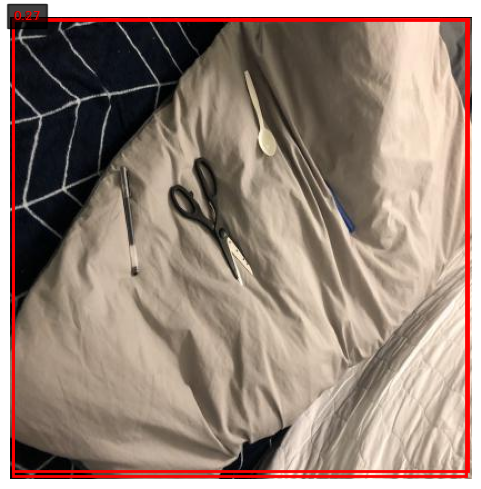

In [ ]:
import torch
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torchvision.transforms import functional as F

# Read image (same style as YOLO)
img = cv2.imread("household.v1i.coco/train/IMG_3239_JPG_jpg.rf.667b6c9162b47abd99046450fd8dc5dd.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to tensor
img_tensor = F.to_tensor(img).unsqueeze(0).to(device)

# Inference
with torch.no_grad():
    outputs = model(img_tensor)[0]

# Threshold
score_thresh = 0.25
boxes = outputs["boxes"][outputs["scores"] > score_thresh]
scores = outputs["scores"][outputs["scores"] > score_thresh]

# Plot 
fig, ax = plt.subplots(1, figsize=(6, 6))
ax.imshow(img)
# bounding boxes have to be manually drawn becuse torchvision models return coordinates rather than a preannotated image
for box, score in zip(boxes, scores):
    x1, y1, x2, y2 = box
    # creating a red rectangle patch for the detection
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)
    # adding the confidence score text
    ax.text(
        x1,
        y1,
        f"{score:.2f}",
        color="red",
        fontsize=9,
        bbox=dict(facecolor="black", alpha=0.5)
    )

ax.axis("off")
plt.show()


Doing a warm up using a real image from the validation data set in preparation for the actual validation loop

In [ ]:
# selectin the first image ID from the COCO validation set
first_img_id = image_ids[0]
# retrieving the metadata fom the image
img_info = coco.loadImgs(first_img_id)[0]
# constructing the full file path
img_path = os.path.join(IMG_DIR, img_info["file_name"])
# loading of the imaage
img = cv2.imread(img_path)
# converting to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# converting to a tensor and then moving it to the CPU
img_tensor = F.to_tensor(img).unsqueeze(0).to(device)
# perform warm up inference
with torch.no_grad():
    _ = model(img_tensor)


Full validation pipeline for the mobilenet to benchmark performance. It mirrors the YOLO validation logic so that a fair comparison can be made late on

In [ ]:
from torchvision.transforms import functional as F
import torch

IOU_THRESHOLD = 0.3

all_ious = []
hits = 0
total_gt = 0

inf_times = []
e2e_times = []

model.eval()
# disabling gradient calculation to improve speed and reduce memory usage
with torch.no_grad():
    for img_id in image_ids:
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(IMG_DIR, img_info["file_name"])

        # Load + preprocess (end-to-end start)
        start_e2e = time.perf_counter()

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_tensor = F.to_tensor(img).unsqueeze(0).to(device)

        # Inference timing
        start_inf = time.perf_counter()
        outputs = model(img_tensor)[0]
        end_inf = time.perf_counter()

        end_e2e = time.perf_counter()
        # storing the timing results in miliseconds
        inf_times.append((end_inf - start_inf) * 1000)
        e2e_times.append((end_e2e - start_e2e) * 1000)

        # Predicted boxes and scores extraction from the model output
        boxes = outputs["boxes"].cpu().numpy()
        scores = outputs["scores"].cpu().numpy()
        # filtering the boxes based on the confidence thereshold
        CONF_THRESH = 0.25
        preds = boxes[scores >= CONF_THRESH]


        # Ground truth boxes
        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        gt_boxes = []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            gt_boxes.append([x, y, x + w, y + h])

        # IoU matching
        for gt in gt_boxes:
            total_gt += 1
            best_iou = 0.0

            for pred in preds:
                iou = compute_iou(gt, pred)
                best_iou = max(best_iou, iou)

            all_ious.append(best_iou)

            if best_iou >= IOU_THRESHOLD:
                hits += 1


Calculation of the evaluation metrics

In [20]:
mean_iou = float(np.mean(all_ious))
recall = hits / total_gt if total_gt > 0 else 0.0

inf_median = float(np.median(inf_times))
inf_p90 = float(np.percentile(inf_times, 90))

e2e_median = float(np.median(e2e_times))
e2e_p90 = float(np.percentile(e2e_times, 90))

Appending the results

In [21]:
import pandas as pd

result_row = {
    "model": "ssdlite320_mobilenet_v3_large",
    "iou_threshold": IOU_THRESHOLD,
    "mean_iou": mean_iou,
    "recall": recall,
    "inf_median_ms": inf_median,
    "inf_p90_ms": inf_p90,
    "e2e_median_ms": e2e_median,
    "e2e_p90_ms": e2e_p90,
}

In [22]:
results_df = pd.concat(
    [results_df, pd.DataFrame([result_row])],
    ignore_index=True
)
results_df

,model,iou_threshold,mean_iou,recall,inf_median_ms,inf_p90_ms,e2e_median_ms,e2e_p90_ms
0,YOLOv8n,0.3,0.514736,0.593103,50.4290,59.1511,66.2866,79.02664
1,ssdlite320_mobilenet_v3_large,0.3,0.434887,0.513793,54.7031,63.9117,58.1850,70.17432


#### EfficientDet

In [ ]:
import torch
from effdet import get_efficientdet_config, EfficientDet, DetBenchPredict
# setting hardware to cpu
device = "cpu"
# loading the configuration for efficientdet
config = get_efficientdet_config("tf_efficientdet_d0")
# 90 is used becuase COCO dataset has 90 categories
config.num_classes = 90
# 512,512 dimension is used becuase that is the dimension that this model is optimized for
config.image_size = (512, 512)
# initializing model
model = EfficientDet(config)
# loading the pretrained weights
model.load_state_dict(
    torch.hub.load_state_dict_from_url(config.url, map_location=device)
)
# wrapper for the model in a helper class so that it can handle the post processing automatically
model = DetBenchPredict(model)
model.to(device)
model.eval()



c:\Users\gohji\anaconda3\envs\ObjectDetection-FYP\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


DetBenchPredict(
  (model): EfficientDet(
    (backbone): EfficientNetFeatures(
      (conv_stem): Conv2dSame(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (bn1): BatchNormAct2d(
        32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): SiLU(inplace=True)
      )
      (blocks): Sequential(
        (0): Sequential(
          (0): DepthwiseSeparableConv(
            (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (bn1): BatchNormAct2d(
              32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): SiLU(inplace=True)
            )
            (aa): Identity()
            (se): SqueezeExcite(
              (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (act1): SiLU(inplace=True)
              (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1

Quick test of the model working and the bounding boxes showing

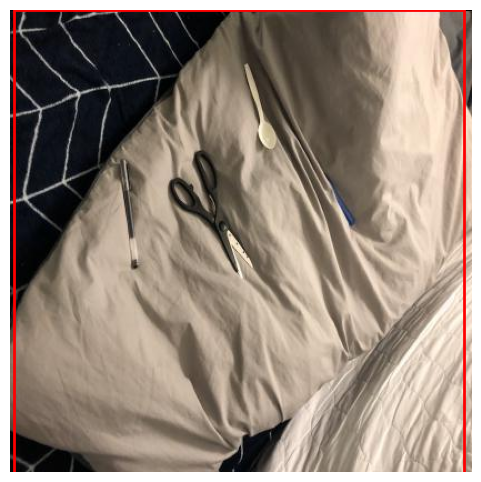

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image_path = "household.v1i.coco/train/IMG_3239_JPG_jpg.rf.667b6c9162b47abd99046450fd8dc5dd.jpg"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h_orig, w_orig = img.shape[:2]

# Resize to EfficientDet-D0 input
img_resized = cv2.resize(img, (512, 512))

# To tensor
img_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float() / 255.0
img_tensor = img_tensor.unsqueeze(0).to(device)

# Inference
with torch.no_grad():
    outputs = model(img_tensor)[0]

# Extract predictions
boxes = outputs[:, :4].cpu().numpy()
scores = outputs[:, 4].cpu().numpy()

# Confidence filtering (same threshold as the 2 models above to ensure consistency)
CONF_THRESH = 0.25
boxes = boxes[scores >= CONF_THRESH]

# Scale boxes back to original image size
boxes[:, [0, 2]] *= w_orig / 512
boxes[:, [1, 3]] *= h_orig / 512

# Plot
plt.figure(figsize=(6, 6))
plt.imshow(img)
for x1, y1, x2, y2 in boxes:
    plt.gca().add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            edgecolor="red",
            linewidth=2
        )
    )
plt.axis("off")
plt.show()


Validation loop for the efficientdet model for performance benchmarking

In [ ]:
IOU_THRESHOLD = 0.3
CONF_THRESH = 0.25
INPUT_SIZE = 512

all_ious = []
hits = 0
total_gt = 0
inf_times = []
e2e_times = []

model.eval()
with torch.no_grad():
    for img_id in image_ids:
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(IMG_DIR, img_info["file_name"])

        # End-to-end start
        start_e2e = time.perf_counter()

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h_orig, w_orig = img.shape[:2]

        # resize for EfficientDet
        img_resized = cv2.resize(img, (INPUT_SIZE, INPUT_SIZE))
        # tensor conversion
        img_tensor = (
            torch.from_numpy(img_resized)
            .permute(2, 0, 1)
            .float() / 255.0
        ).unsqueeze(0).to(device)

        # Inference timing
        start_inf = time.perf_counter()
        outputs = model(img_tensor)[0]
        end_inf = time.perf_counter()

        end_e2e = time.perf_counter()

        inf_times.append((end_inf - start_inf) * 1000)
        e2e_times.append((end_e2e - start_e2e) * 1000)

        # extract predicted boxes and scores
        boxes = outputs[:, :4].cpu().numpy()
        scores = outputs[:, 4].cpu().numpy()
        # filtering
        keep = scores >= CONF_THRESH
        boxes = boxes[keep]

        # scale boxes back to original image size
        boxes[:, [0, 2]] *= w_orig / INPUT_SIZE
        boxes[:, [1, 3]] *= h_orig / INPUT_SIZE

        # Ground truth
        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        gt_boxes = []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            gt_boxes.append([x, y, x + w, y + h])

        # IoU matching
        for gt in gt_boxes:
            total_gt += 1
            best_iou = 0.0

            for pred in boxes:
                best_iou = max(best_iou, compute_iou(gt, pred))

            all_ious.append(best_iou)
            if best_iou >= IOU_THRESHOLD:
                hits += 1


In [26]:
mean_iou = float(np.mean(all_ious))
recall = hits / total_gt if total_gt > 0 else 0.0

inf_median = float(np.median(inf_times))
inf_p90 = float(np.percentile(inf_times, 90))

e2e_median = float(np.median(e2e_times))
e2e_p90 = float(np.percentile(e2e_times, 90))

Appending the results to the exising dataset

In [27]:
import pandas as pd

result_row = {
    "model": "tf_efficientdet_d0",
    "iou_threshold": IOU_THRESHOLD,
    "mean_iou": mean_iou,
    "recall": recall,
    "inf_median_ms": inf_median,
    "inf_p90_ms": inf_p90,
    "e2e_median_ms": e2e_median,
    "e2e_p90_ms": e2e_p90,
}

In [28]:
results_df = pd.concat(
    [results_df, pd.DataFrame([result_row])],
    ignore_index=True
)
results_df

,model,iou_threshold,mean_iou,recall,inf_median_ms,inf_p90_ms,e2e_median_ms,e2e_p90_ms
0,YOLOv8n,0.3,0.514736,0.593103,50.4290,59.15110,66.2866,79.02664
1,ssdlite320_mobilenet_v3_large,0.3,0.434887,0.513793,54.7031,63.91170,58.1850,70.17432
2,tf_efficientdet_d0,0.3,0.360493,0.431034,163.2540,180.38624,167.7779,187.29194


#### R-CNN(with resnet-50)

Initiating and loading R-CNN model

In [ ]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn

device = "cpu"
# loading fastercnn with the resnet 50 backbone
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
model.to(device)
model.eval()



FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

Quick test to see if model works and the bounding box is displayed

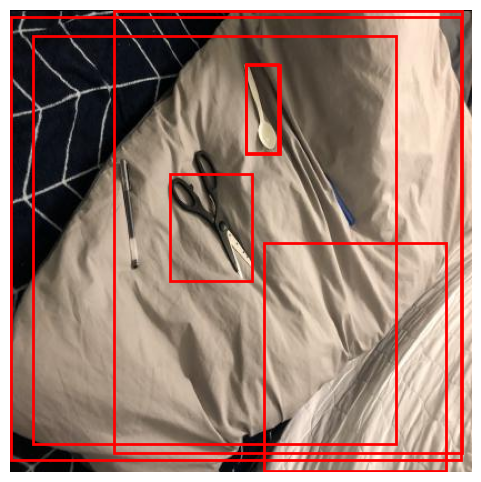

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import functional as F

CONF_THRESH = 0.25

image_path = "household.v1i.coco/train/IMG_3239_JPG_jpg.rf.667b6c9162b47abd99046450fd8dc5dd.jpg"

# Load image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# To tensor
img_tensor = F.to_tensor(img).unsqueeze(0).to(device)

# Inference
with torch.no_grad():
    outputs = model(img_tensor)[0]

# Extract boxes + scores
boxes = outputs["boxes"].cpu().numpy()
scores = outputs["scores"].cpu().numpy()

# Confidence filtering
boxes = boxes[scores >= CONF_THRESH]

# Plot
plt.figure(figsize=(6, 6))
plt.imshow(img)
for x1, y1, x2, y2 in boxes:
    plt.gca().add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            edgecolor="red",
            linewidth=2
        )
    )
plt.axis("off")
plt.show()


Validation loop for the R-CNN model to measure its performance

In [ ]:
IOU_THRESHOLD = 0.3
CONF_THRESH = 0.25

all_ious = []
hits = 0
total_gt = 0
inf_times = []
e2e_times = []

model.eval()
with torch.no_grad():
    for img_id in image_ids:
        # fetching image metadata and path from COCO dataset
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(IMG_DIR, img_info["file_name"])

        # start end to end timer
        start_e2e = time.perf_counter()
        # preprocessing
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_tensor = F.to_tensor(img).unsqueeze(0).to(device)

        # Inference timing
        start_inf = time.perf_counter()
        outputs = model(img_tensor)[0]
        end_inf = time.perf_counter()

        end_e2e = time.perf_counter()

        inf_times.append((end_inf - start_inf) * 1000)
        e2e_times.append((end_e2e - start_e2e) * 1000)

        # extracting boxes and score
        boxes = outputs["boxes"].cpu().numpy()
        scores = outputs["scores"].cpu().numpy()

        boxes = boxes[scores >= CONF_THRESH]

        # ground truth
        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        # converting COCO to match the output
        gt_boxes = []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            gt_boxes.append([x, y, x + w, y + h])

        # IoU matching
        for gt in gt_boxes:
            total_gt += 1
            best_iou = 0.0

            for pred in boxes:
                best_iou = max(best_iou, compute_iou(gt, pred))

            all_ious.append(best_iou)
            if best_iou >= IOU_THRESHOLD:
                hits += 1


In [32]:
mean_iou = float(np.mean(all_ious))
recall = hits / total_gt if total_gt > 0 else 0.0

inf_median = float(np.median(inf_times))
inf_p90 = float(np.percentile(inf_times, 90))

e2e_median = float(np.median(e2e_times))
e2e_p90 = float(np.percentile(e2e_times, 90))

Appending results to the existing dataframe

In [33]:
import pandas as pd

result_row = {
    "model": "fasterrcnn_resnet50_fpn",
    "iou_threshold": IOU_THRESHOLD,
    "mean_iou": mean_iou,
    "recall": recall,
    "inf_median_ms": inf_median,
    "inf_p90_ms": inf_p90,
    "e2e_median_ms": e2e_median,
    "e2e_p90_ms": e2e_p90,
}

In [34]:
results_df = pd.concat(
    [results_df, pd.DataFrame([result_row])],
    ignore_index=True
)
results_df

,model,iou_threshold,mean_iou,recall,inf_median_ms,inf_p90_ms,e2e_median_ms,e2e_p90_ms
0,YOLOv8n,0.3,0.514736,0.593103,50.4290,59.15110,66.2866,79.02664
1,ssdlite320_mobilenet_v3_large,0.3,0.434887,0.513793,54.7031,63.91170,58.1850,70.17432
2,tf_efficientdet_d0,0.3,0.360493,0.431034,163.2540,180.38624,167.7779,187.29194
3,fasterrcnn_resnet50_fpn,0.3,0.685752,0.800000,1158.1629,1524.80644,1159.3823,1528.28982


### Analysis of model results

In [35]:
results_df

,model,iou_threshold,mean_iou,recall,inf_median_ms,inf_p90_ms,e2e_median_ms,e2e_p90_ms
0,YOLOv8n,0.3,0.514736,0.593103,50.4290,59.15110,66.2866,79.02664
1,ssdlite320_mobilenet_v3_large,0.3,0.434887,0.513793,54.7031,63.91170,58.1850,70.17432
2,tf_efficientdet_d0,0.3,0.360493,0.431034,163.2540,180.38624,167.7779,187.29194
3,fasterrcnn_resnet50_fpn,0.3,0.685752,0.800000,1158.1629,1524.80644,1159.3823,1528.28982


YOLOv8n was selected as the most suitable object detection model for this application due to its ability to deliver extremely low latency while maintaining sufficient detection accuracy for the system’s requirements. The primary objective of the system is to rapidly identify an item and draw a bounding box around it in order to provide immediate feedback. As such, inference speed and end to end response time are prioritised over maximising detection accuracy. The evaluation results show that YOLOv8n achieves the fastest performance among all tested models, with a median inference time of approximately 50.4 ms and an end to end median latency of around 66.2 ms. This allows the system to operate in near real time and respond quickly to user input, which is essential for the intended use case.

In contrast, although Faster R CNN with a ResNet 50 backbone achieves the highest mean IoU and recall values, its computational cost is significantly higher. The model exhibits a median inference time exceeding 1 second. Such delays make the model impractical for real time deployment, as the system would feel unresponsive and fail to meet usability requirements. While Faster R CNN offers superior detection accuracy, the trade off in latency is too large to justify its use in a time critical application. Therefore, despite its stronger accuracy metrics, it is not a feasible option for this system.

The mean IoU achieved by YOLOv8n is approximately 0.51, which is lower than that of Faster R CNN but remains appropriate for the task. Mean IoU measures the overlap between predicted and ground truth bounding boxes, and in this application, precise box alignment is not critical. The goal is to reliably localise the item and provide a clear visual indication of its position rather than achieve pixel perfect bounding boxes. As long as the detected box sufficiently encloses the target object, the system can function as intended. Consequently, the IoU achieved by YOLOv8n is considered good enough for effective object localisation in this context.

Similarly, YOLOv8n achieves a recall of approximately 0.59, indicating that the model successfully detects the object in the majority of relevant cases. Although this recall is lower than that of Faster R CNN, it is acceptable given the system’s emphasis on speed and responsiveness. The application is designed to operate continuously, meaning that occasional missed detections can be corrected in subsequent frames. Prioritising higher recall at the expense of significantly increased latency would reduce the overall usability of the system. Therefore, the recall performance of YOLOv8n represents a reasonable balance between detection reliability and real time operation.

Mean Average Precision is not reported in this evaluation because the task does not involve multi class ranking or performance comparison across confidence thresholds. The objective is limited to identifying the presence of an item and drawing a bounding box around it. As such, mean IoU and recall are more directly aligned with the functional requirements of the system and provide sufficient insight into detection quality for this use case.

Overall, YOLOv8n provides the best trade off between detection performance and computational efficiency. It delivers the fastest inference and end to end response times while maintaining adequate mean IoU and recall for reliable object localisation. Although other models achieve higher accuracy metrics, their latency makes them unsuitable for real time deployment. Therefore, YOLOv8n is the most appropriate choice for this application given its strict low latency requirements.

### Comparison with the YOLOv8n families

To further evaluate the chosen model, a slightly larger variant(YOLOv8s) within the same YOLO family is also included for comparison. This allows analysis of whether the increase in model capacity leads to meaningful gains in detection accuracy, and whether these improvements justify the associated trade offs in inference speed and computational cost. The comparison focuses on assessing if the performance gains are substantial enough to warrant the additional resource requirements.

In [ ]:
from ultralytics import YOLO
import torch

device = "cpu"
# loadind a slighly larger YOLO model
model = YOLO("yolov8s.pt")
model.to(device)



YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_s

Initialise data using COCO dataset

In [ ]:
import os
import cv2
import numpy as np
from pycocotools.coco import COCO
# directory path for validation datset
DATA_DIR = "household.v1i.coco/valid"
IMG_DIR = os.path.join(DATA_DIR)
ANN_PATH = os.path.join(DATA_DIR, "_annotations.coco.json")

coco = COCO(ANN_PATH)
image_ids = coco.getImgIds()


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


Warm up for the model

In [ ]:
# selecting the first image 
first_img_id = image_ids[0]
# retrieving metadata
img_info = coco.loadImgs(first_img_id)[0]
# construct full file path
img_path = os.path.join(IMG_DIR, img_info["file_name"])
# loading the image into memory
dummy = cv2.imread(img_path)
# warming up model
_ = model(dummy, device=device)



0: 640x640 1 bottle, 3 cups, 2 spoons, 1 dining table, 174.3ms
Speed: 13.4ms preprocess, 174.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


Performing validation for performance benchmarking

In [ ]:
IOU_THRESHOLD = 0.3

all_ious = []
hits = 0
total_gt = 0

inf_times = []
e2e_times = []

for img_id in image_ids:
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(IMG_DIR, img_info["file_name"])

    # Load image
    start_e2e = time.perf_counter()
    img = cv2.imread(img_path)

    # Inference timing
    start_inf = time.perf_counter()
    results = model(img, device=device, verbose=False)
    end_inf = time.perf_counter()

    end_e2e = time.perf_counter()

    inf_times.append((end_inf - start_inf) * 1000)
    e2e_times.append((end_e2e - start_e2e) * 1000)

    # Predicted boxes
    preds = results[0].boxes.xyxy.cpu().numpy()

    # Ground truth boxes
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    gt_boxes = []
    for ann in anns:
        x, y, w, h = ann["bbox"]
        gt_boxes.append([x, y, x + w, y + h])

    # IoU matching
    for gt in gt_boxes:
        total_gt += 1
        best_iou = 0.0

        for pred in preds:
            iou = compute_iou(gt, pred)
            best_iou = max(best_iou, iou)

        all_ious.append(best_iou)

        if best_iou >= IOU_THRESHOLD:
            hits += 1

In [41]:
mean_iou = float(np.mean(all_ious))
recall = hits / total_gt if total_gt > 0 else 0.0

inf_median = float(np.median(inf_times))
inf_p90 = float(np.percentile(inf_times, 90))

e2e_median = float(np.median(e2e_times))
e2e_p90 = float(np.percentile(e2e_times, 90))

Copying the first row of the previous dataframe (the first row consist of the results for YOLOv8n) so a new dataframe can be made so analysis between the two could be made.

In [42]:
compare_within_family_df = results_df.iloc[[0]].copy()


In [44]:
import pandas as pd

result_row = {
    "model": "YOLOv8s",
    "iou_threshold": IOU_THRESHOLD,
    "mean_iou": mean_iou,
    "recall": recall,
    "inf_median_ms": inf_median,
    "inf_p90_ms": inf_p90,
    "e2e_median_ms": e2e_median,
    "e2e_p90_ms": e2e_p90,
}


In [45]:
compare_within_family_df = pd.concat(
    [compare_within_family_df, pd.DataFrame([result_row])],
    ignore_index=True
)
compare_within_family_df

,model,iou_threshold,mean_iou,recall,inf_median_ms,inf_p90_ms,e2e_median_ms,e2e_p90_ms
0,YOLOv8n,0.3,0.514736,0.593103,50.429,59.1511,66.2866,79.02664
1,YOLOv8s,0.3,0.551273,0.624138,119.630,128.5135,133.5197,145.27318


Although YOLOv8s demonstrates marginal improvements in mean IoU and recall compared to YOLOv8n, the gains are achieved at the cost of significantly increased inference and end to end latency. Given the CPU-only deployment constraint, YOLOv8n offers a more favorable balance between detection performance and computational efficiency, and is therefore selected for subsequent analysis.

### Detection of Common Household Furniture

This section presents a preliminary evaluation of the model’s ability to detect and label common household furniture, such as chairs and sofas, to provide contextual information for a user labelled object locator system.

In [52]:
from ultralytics import YOLO
import numpy as np

device = "cpu"

# Explicitly reload YOLOv8n
model = YOLO("yolov8n.pt")
model.to(device)

# Warm up
dummy = np.zeros((640, 640, 3), dtype=np.uint8)
_ = model(dummy, device=device, verbose=False)


3 images are loaded in and the class label is extracted. The confidence score is also included. This is to give a quick test to see if the model can indeed identify to a certain extent these common household furniture

In [ ]:
image_paths = [
    "sofa.jpeg",
    "bed.jpeg",
    "table.jpeg"
]
# processing all of the images at once
results = model(image_paths, device=device, verbose=False)
# loop through each image path and its corresponding model output
for img_path, result in zip(image_paths, results):
    print(f"\nResults for {img_path}:")
    for box in result.boxes:
        # convert the numeric class ID to a human readable name
        cls_id = int(box.cls.item())
        label = model.names[cls_id]
        # obtaining the confidence score 
        conf = float(box.conf.item())
        print(f"  {label} ({conf:.2f})")

    # saving a copy of the image with bounding boxes drawn so they can be visually checked
    result.save(filename=f"out_{img_path}")


Results for sofa.jpeg:
  book (0.31)

Results for bed.jpeg:
  bed (0.80)

Results for table.jpeg:
  chair (0.57)
  backpack (0.52)
  chair (0.42)


Qualitative results show that the pretrained YOLOv8n model is able to detect several common household objects, including beds and chairs, with varying confidence levels. Detection performance is influenced by object visibility, clutter, and alignment with COCO category definitions. While certain furniture items such as sofas and tables are not consistently detected in complex scenes, the model still provides useful contextual cues through the identification of surrounding objects. This level of contextual awareness is sufficient for supporting the object locator system, where primary object identification is performed by the user.

To ensure that only high-confidence object classifications are used to support scene descriptions, a confidence threshold of 0.5 was applied. This threshold reduces spurious detections while retaining reliably recognised household objects. In this context, it is preferable to omit uncertain surrounding objects rather than risk providing incorrect contextual information to the user, as misleading context may negatively impact object localisation.

## Appendix

Stage 1 Dataset used: https://universe.roboflow.com/yolov5-epx0y/household-uhdlf/browse?queryText=&pageSize=50&startingIndex=0&browseQuery=true